<a href="https://colab.research.google.com/github/Katherine-Rosales/thematic-maps-mobiles/blob/main/thematic_maps_mobiles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mapas temáticos para el análisis de la variable MOBILES en América

En este trabajo se unirán los datos del mapa con la información del archivo CSV para analizar la variable MOBILES en los países de Norteamérica, Sudamérica, Centroamérica y el Caribe. A partir de esta información  se elaborarán los tres mapas temáticos vistos en clase.

In [1]:
import geopandas as gpd

linkGit='https://github.com/Katherine-Rosales/thematic-maps-mobiles/raw/main/'
linkWorldMaps='worldMaps.gpkg'

In [2]:
gpd.list_layers(linkGit+linkWorldMaps)

,name,geometry_type
0,rivers,MultiLineString
1,cities,Point
2,countries,MultiPolygon


In [3]:
countries = gpd.read_file(linkGit + linkWorldMaps, layer='countries')
countries

,COUNTRY,geometry
0,Aruba (Netherlands),"MULTIPOLYGON (((-69.88223 12.41111, -69.94695 ..."
1,Antigua and Barbuda,"MULTIPOLYGON (((-61.73889 17.54055, -61.75195 ..."
2,Afghanistan,"MULTIPOLYGON (((61.27656 35.60725, 61.29638 35..."
3,Algeria,"MULTIPOLYGON (((-5.15213 30.18047, -5.13917 30..."
4,Azerbaijan,"MULTIPOLYGON (((46.54037 38.87559, 46.49554 38..."
...,...,...
247,South Sudan,"MULTIPOLYGON (((34.21807 9.96458, 34.20722 9.9..."
248,Indonesia,"MULTIPOLYGON (((123.21846 -10.80917, 123.19832..."
249,East Timor,"MULTIPOLYGON (((124.41824 -9.3001, 124.40446 -..."
250,Curacao (Netherlands),"MULTIPOLYGON (((-68.96556 12.19889, -68.91196 ..."


In [4]:
import pandas as pd

someDataLink = 'some_dataworld.csv'
someData = pd.read_csv(linkGit + someDataLink)

someData

,Country,iso2,iso3,region,fragility,co2,sq_km,num_airports,population,mobiles
0,AFGHANISTAN,AF,AFG,SOUTH ASIA,105.0,7893000,652230,68,40121552,23000000
1,ALBANIA,AL,ALB,EUROPE,58.9,3794000,28748,3,3107100,2610000
2,ALGERIA,DZ,DZA,AFRICA,75.4,151633000,2381740,95,47022473,51500000
3,ANGOLA,AO,AGO,AFRICA,87.8,19362000,1246700,107,37202061,25700000
4,ANTIGUA AND BARBUDA,AG,ATG,CENTRAL AMERICA AND THE CARIBBEAN,54.4,729000,443,4,102634,184000
...,...,...,...,...,...,...,...,...,...,...
166,VENEZUELA,VE,VEN,SOUTH AMERICA,90.0,76730000,912050,509,31250306,18800000
167,VIETNAM,VN,VNM,EAST AND SOUTHEAST ASIA,66.1,249929000,331210,36,105758975,131000000
168,YEMEN,YE,YEM,MIDDLE EAST,113.5,10158000,527968,37,32140443,20000000
169,ZAMBIA,ZM,ZMB,AFRICA,85.7,6798000,752618,120,20799116,21200000


## Preparación para unir los datos

In [5]:
countries.COUNTRY.head()

,COUNTRY
0,Aruba (Netherlands)
1,Antigua and Barbuda
2,Afghanistan
3,Algeria
4,Azerbaijan


In [6]:
someData.Country.head()

,Country
0,AFGHANISTAN
1,ALBANIA
2,ALGERIA
3,ANGOLA
4,ANTIGUA AND BARBUDA


In [7]:
countries.rename(columns={'COUNTRY':'Country'}, inplace=True)

In [8]:
countries['Country'] = countries.Country.str.upper()

In [9]:
countries.Country.head()

,Country
0,ARUBA (NETHERLANDS)
1,ANTIGUA AND BARBUDA
2,AFGHANISTAN
3,ALGERIA
4,AZERBAIJAN


Es poco probable que los nombres de los países estén escritos exactamente igual en ambos archivos.

In [10]:
onlyDF = set(someData.Country) - set(countries.Country)
onlyGDF = set(countries.Country) - set(someData.Country)

In [11]:
onlyDF

{'BAHAMAS (THE)',
 'BOLIVIA (PLURINATIONAL STATE OF)',
 'BRUNEI DARUSSALAM',
 'CABO VERDE',
 'CENTRAL AFRICAN REPUBLIC (THE)',
 'COMOROS (THE)',
 'CONGO (THE DEMOCRATIC REPUBLIC OF THE)',
 'CONGO (THE)',
 "CÔTE D'IVOIRE",
 'DOMINICAN REPUBLIC (THE)',
 'ESWATINI',
 'GAMBIA (THE)',
 'IRAN (ISLAMIC REPUBLIC OF)',
 'KOREA (THE REPUBLIC OF)',
 "LAO PEOPLE'S DEMOCRATIC REPUBLIC (THE)",
 'MICRONESIA (FEDERATED STATES OF)',
 'MOLDOVA (THE REPUBLIC OF)',
 'NETHERLANDS (THE)',
 'NIGER (THE)',
 'NORTH MACEDONIA',
 'NORTHERN MARIANA ISLANDS (THE)',
 'PHILIPPINES (THE)',
 'RUSSIAN FEDERATION (THE)',
 'SAMOA',
 'SUDAN (THE)',
 'TANZANIA, THE UNITED REPUBLIC OF',
 'TIMOR-LESTE',
 'UNITED ARAB EMIRATES (THE)',
 'UNITED KINGDOM OF GREAT BRITAIN AND NORTHERN IRELAND (THE)',
 'UNITED STATES OF AMERICA (THE)'}

### Búsqueda de coincidencias entre nombres de países

Como algunos países están escritos de forma diferente en ambos archivos, se buscará el nombre más parecido para poder relacionarlos correctamente.

In [12]:
!pip install thefuzz

In [13]:
from thefuzz.process import extractOne as best

In [14]:
regions = [
    'NORTH AMERICA',
    'SOUTH AMERICA',
    'CENTRAL AMERICA AND THE CARIBBEAN'
]

americanData = someData[someData.region.isin(regions)]

In [15]:
americaMissing = set(americanData.Country) - set(countries.Country)

[(country, best(country, onlyGDF)) for country in americaMissing]

[('UNITED STATES OF AMERICA (THE)', ('UNITED STATES', 90)),
 ('DOMINICAN REPUBLIC (THE)', ('DOMINICAN REPUBLIC', 95)),
 ('BOLIVIA (PLURINATIONAL STATE OF)', ('BOLIVIA', 90)),
 ('BAHAMAS (THE)', ('BAHAMAS', 90))]

Las coincidencias encontradas para los países de América son correctas, por lo que se actualizarán sus nombres antes de realizar la unión.

In [16]:
changesToDF = {country: best(country, onlyGDF)[0] for country in americaMissing}
changesToDF

{'UNITED STATES OF AMERICA (THE)': 'UNITED STATES',
 'DOMINICAN REPUBLIC (THE)': 'DOMINICAN REPUBLIC',
 'BOLIVIA (PLURINATIONAL STATE OF)': 'BOLIVIA',
 'BAHAMAS (THE)': 'BAHAMAS'}

In [17]:
someData.replace(to_replace={'Country': changesToDF}, inplace=True)

In [18]:
americanData = someData[someData.region.isin(regions)]

set(americanData.Country) - set(countries.Country)

set()

## Unión de los datos

In [19]:
worldData = countries.merge(someData, on='Country')
worldData

,Country,geometry,iso2,iso3,region,fragility,co2,sq_km,num_airports,population,mobiles
0,ANTIGUA AND BARBUDA,"MULTIPOLYGON (((-61.73889 17.54055, -61.75195 ...",AG,ATG,CENTRAL AMERICA AND THE CARIBBEAN,54.4,729000,443,4,102634,184000
1,AFGHANISTAN,"MULTIPOLYGON (((61.27656 35.60725, 61.29638 35...",AF,AFG,SOUTH ASIA,105.0,7893000,652230,68,40121552,23000000
2,ALGERIA,"MULTIPOLYGON (((-5.15213 30.18047, -5.13917 30...",DZ,DZA,AFRICA,75.4,151633000,2381740,95,47022473,51500000
3,AZERBAIJAN,"MULTIPOLYGON (((46.54037 38.87559, 46.49554 38...",AZ,AZE,MIDDLE EAST,73.2,35389000,86600,32,10650239,11000000
4,ALBANIA,"MULTIPOLYGON (((20.79192 40.43154, 20.78722 40...",AL,ALB,EUROPE,58.9,3794000,28748,3,3107100,2610000
...,...,...,...,...,...,...,...,...,...,...,...
140,YEMEN,"MULTIPOLYGON (((48.68639 14.0375, 48.61 14.044...",YE,YEM,MIDDLE EAST,113.5,10158000,527968,37,32140443,20000000
141,ZAMBIA,"MULTIPOLYGON (((30.21302 -14.98172, 30.21917 -...",ZM,ZMB,AFRICA,85.7,6798000,752618,120,20799116,21200000
142,ZIMBABWE,"MULTIPOLYGON (((32.48888 -21.34445, 32.46541 -...",ZW,ZWE,AFRICA,99.5,7902000,390757,144,17150352,15000000
143,SOUTH SUDAN,"MULTIPOLYGON (((34.21807 9.96458, 34.20722 9.9...",SS,SSD,AFRICA,112.2,1778000,644329,89,12703714,6170000


## Selección de las regiones de América

In [20]:
america = worldData[worldData.region.isin(regions)].copy()
america

,Country,geometry,iso2,iso3,region,fragility,co2,sq_km,num_airports,population,mobiles
0,ANTIGUA AND BARBUDA,"MULTIPOLYGON (((-61.73889 17.54055, -61.75195 ...",AG,ATG,CENTRAL AMERICA AND THE CARIBBEAN,54.4,729000,443,4,102634,184000
7,ARGENTINA,"MULTIPOLYGON (((-71.01648 -36.47591, -70.98195...",AR,ARG,SOUTH AMERICA,46.0,193205000,2780400,764,46994384,62700000
11,BARBADOS,"MULTIPOLYGON (((-59.53306 13.05055, -59.54542 ...",BB,BRB,CENTRAL AMERICA AND THE CARIBBEAN,48.0,1703000,430,1,304139,323000
14,BAHAMAS,"MULTIPOLYGON (((-77.95029 26.89778, -77.91695 ...",BS,BHS,CENTRAL AMERICA AND THE CARIBBEAN,48.8,3984000,13880,54,410862,400000
16,BELIZE,"MULTIPOLYGON (((-88.28914 17.1225, -88.28001 1...",BZ,BLZ,CENTRAL AMERICA AND THE CARIBBEAN,62.5,541000,22966,27,415789,264000
18,BOLIVIA,"MULTIPOLYGON (((-62.19884 -20.47139, -62.26945...",BO,BOL,SOUTH AMERICA,72.9,17786000,1098581,201,12311974,12000000
22,BRAZIL,"MULTIPOLYGON (((-70.62862 -9.94849, -70.62889 ...",BR,BRA,SOUTH AMERICA,71.8,456670000,8515770,5297,220051512,213000000
26,CANADA,"MULTIPOLYGON (((-84.47945 77.29443, -84.46764 ...",CA,CAN,NORTH AMERICA,20.0,612084000,9984670,1459,38794813,36500000
31,CHILE,"MULTIPOLYGON (((-73.61806 -51.6339, -73.60494 ...",CL,CHL,SOUTH AMERICA,38.9,88333000,756102,379,18664652,26700000
33,COLOMBIA,"MULTIPOLYGON (((-81.71306 12.49028, -81.72014 ...",CO,COL,SOUTH AMERICA,75.7,81007000,1138910,661,49588357,87400000


In [21]:
america.region.value_counts()

,count
region,
CENTRAL AMERICA AND THE CARIBBEAN,16
SOUTH AMERICA,12
NORTH AMERICA,3


# Mapa de densidad de puntos

En este mapa, cada punto representará una cantidad fija de usuarios de teléfonos móviles. Mientras mayor sea la cantidad de puntos dentro de un país, mayor será el valor de la variable MOBILES.

In [22]:
america.mobiles.describe()

,mobiles
count,3.100000e+01
mean,3.714639e+07
std,7.925702e+07
min,1.120000e+05
25%,2.645000e+06
50%,7.920000e+06
75%,2.365000e+07
max,3.860000e+08


In [23]:
justDots = america.copy()

dot_value = 100000
justDots['num_dots'] = (justDots['mobiles'] / dot_value).astype(int)

In [24]:
justDots = justDots.sample_points(
    size=justDots['num_dots']
).explode(index_parts=True)

In [25]:
justDots.reset_index(drop=True, inplace=True)
america_dots = gpd.GeoDataFrame(geometry=justDots)

<Axes: >

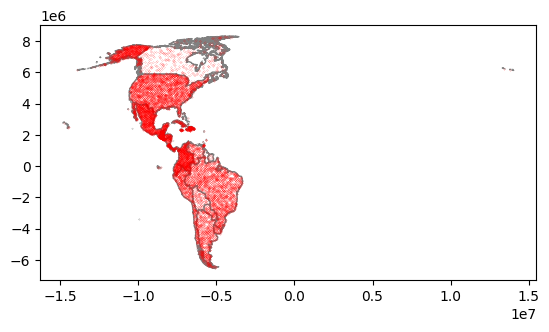

In [26]:
base = america.to_crs(8857).plot(
    facecolor='white',
    edgecolor='grey'
)

america_dots.to_crs(8857).plot(
    markersize=0.01,
    color='red',
    ax=base
)

Cada punto representa 100 000 usuarios de teléfonos móviles.

# Mapa de símbolos proporcionales

El tamaño de cada símbolo representa la cantidad de usuarios de teléfonos móviles en cada país.

<Axes: >

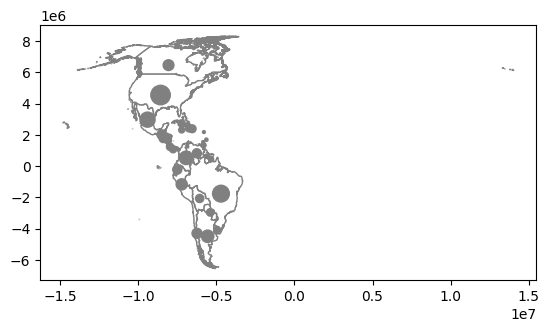

In [27]:
symbols = america.to_crs(8857).copy()
symbols['geometry'] = symbols.representative_point()
symbols['size'] = symbols['mobiles'].apply(lambda x: x**0.5/100)

base = america.to_crs(8857).plot(
    facecolor='white',
    edgecolor='grey'
)

symbols.plot(
    ax=base,
    markersize=symbols['size'],
    color='grey'
)

# Mapa coroplético

Para comparar los países, la variable MOBILES se normaliza con respecto a la población, obteniendo la cantidad de suscripciones móviles por cada 100 habitantes.

In [28]:
america['mobiles_100'] = (america['mobiles'] / america['population']) * 100

In [29]:
import mapclassify
import numpy as np

np.random.seed(12345)

K = 5
theVar = america['mobiles_100']

ei5 = mapclassify.EqualInterval(theVar, k=K)
msd = mapclassify.StdMean(theVar)
q5 = mapclassify.Quantiles(theVar, k=K)
mb5 = mapclassify.MaximumBreaks(theVar, k=K)
ht = mapclassify.HeadTailBreaks(theVar)
fj5 = mapclassify.FisherJenks(theVar, k=K)
jc5 = mapclassify.JenksCaspall(theVar, k=K)
mp5 = mapclassify.MaxP(theVar, k=K)

class5 = [ei5, msd, q5, mb5, ht, fj5, jc5, mp5]

adcms = pd.DataFrame({
    'ADCM': [c.adcm for c in class5],
    'Classifier': [c.name for c in class5]
})

adcms.sort_values('ADCM')

,ADCM,Classifier
5,117.566605,FisherJenks
6,120.089921,JenksCaspall
0,141.228171,EqualInterval
3,171.556708,MaximumBreaks
2,242.239796,Quantiles
7,266.252263,MaxP
4,308.807067,HeadTailBreaks
1,367.172704,StdMean


<Axes: ylabel='Classifier'>

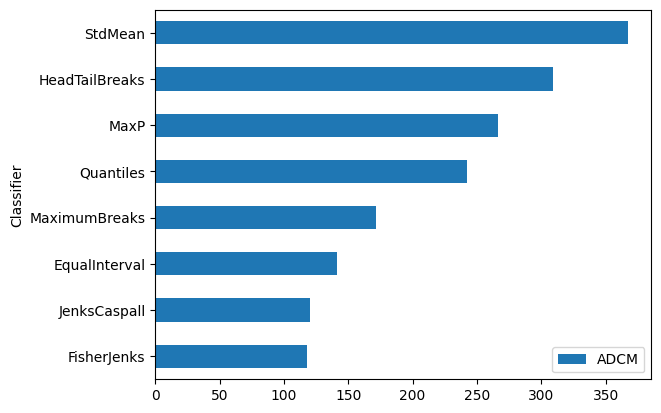

In [30]:
adcms.sort_values('ADCM').plot.barh(x='Classifier')

<Axes: >

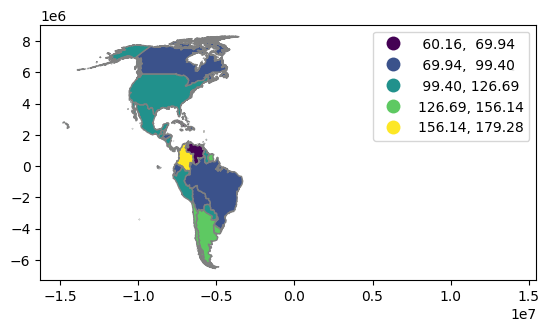

In [31]:
america.to_crs(8857).plot(
    column='mobiles_100',
    scheme='FisherJenks',
    k=5,
    legend=True,
    edgecolor='grey'
)